<a href="https://colab.research.google.com/github/nishanthdb5159-sys/SIGN-LANGUAGE-RECOGNITION-USING-CNN-WITH-INCEPTIONRESNETV2/blob/main/Sign_Language_Projext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
import shutil
import random

In [ ]:
print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Sign_Data.zip to Sign_Data.zip


In [ ]:
import zipfile
zip_path='Sign_Data.zip'
extract_path='/content/sample_data'
with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall(extract_path)

In [ ]:
extract_path='/content/sample_data/Sign_Data/'
file_list=os.listdir(extract_path)
print(file_list)

['8', 'K', 'U', '6', '5', 'H', 'B', '2', 'E', 'O', 'W', 'L', '4', 'M', 'Y', 'V', 'N', 'P', 'Q', 'I', '7', 'A', 'R', 'X', 'S', 'T', 'J', 'Z', '9', '3', '1', 'C', 'D', 'G', 'F']


In [ ]:
classes = os.listdir(extract_path)
filepaths = []
labels = []
for d in classes:
    flist = os.listdir(extract_path + d)
    for f in flist:
        fpath = os.path.join(extract_path + d + '/' + f)
        filepaths.append(fpath)
        labels.append(d)
print ('filepaths: ', len(filepaths), '   labels: ', len(labels))

filepaths:  31712    labels:  31712


In [ ]:
Fseries=pd.Series(filepaths, name='file_paths')
Lseries=pd.Series(labels, name='labels')
df=pd.concat([Fseries,Lseries], axis=1)
df=pd.DataFrame(np.array(df).reshape(31712,2), columns = ['file_paths', 'labels'])
print(df['labels'].value_counts())

labels
I    1079
V     980
G     911
Z     909
1     900
8     900
K     900
W     900
5     900
B     900
H     900
P     900
N     900
M     900
4     900
Q     900
E     900
L     900
2     900
F     900
D     900
3     900
7     900
S     900
J     900
A     900
R     900
9     900
U     899
Y     899
T     899
X     898
C     897
6     890
O     851
Name: count, dtype: int64


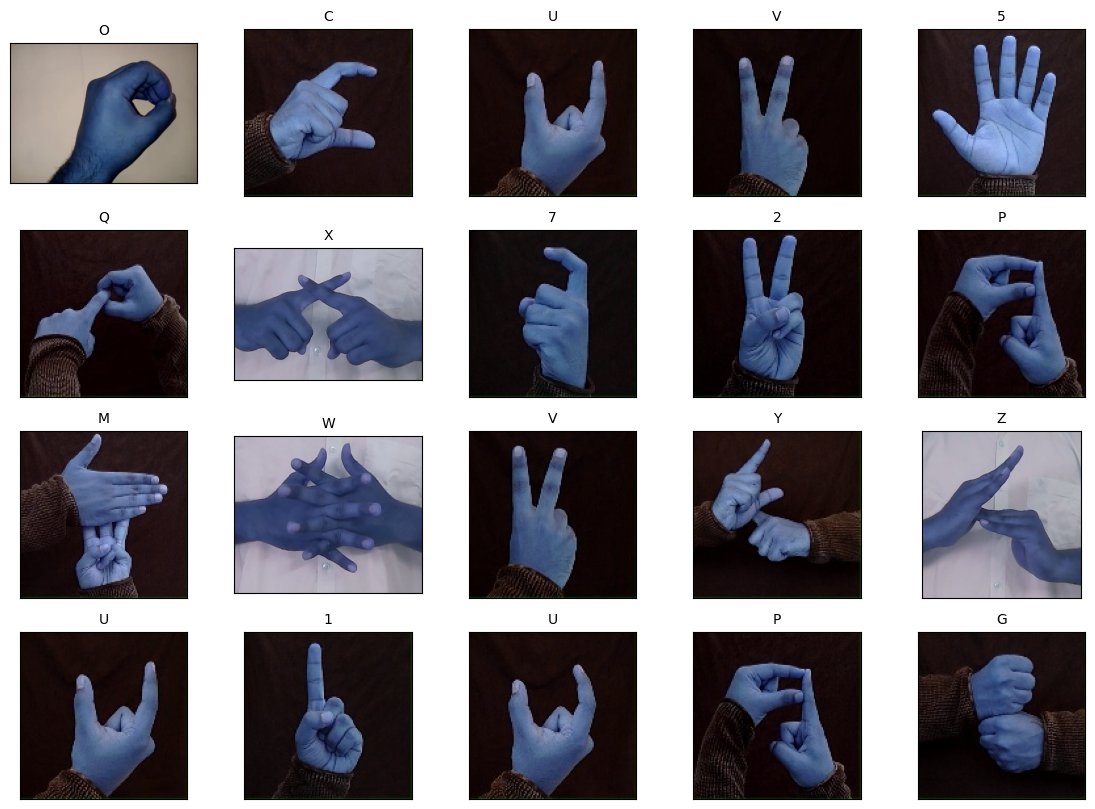

In [ ]:
plt.figure(figsize=(14,10))
for i in range(20):
    random = np.random.randint(1,len(df))
    plt.subplot(4,5,i+1)
    plt.imshow(cv2.imread(df.loc[random,"file_paths"]))
    plt.title(df.loc[random, "labels"], size = 10, color = "black")
    plt.xticks([])
    plt.yticks([])

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, train_size=0.95, random_state=0)
train_df, val_df = train_test_split(train_df, train_size=0.9, random_state=0)
print(f'Train DF Conatins {train_df.labels.value_counts()}')
print(f'Validation DF Conatins {val_df.labels.value_counts()}')
print(f'Test DF Conatins {test_df.labels.value_counts()}')

Train DF Conatins labels
I    923
V    833
H    795
F    786
7    786
A    783
C    782
3    781
M    780
W    779
4    778
E    777
Z    774
X    773
G    772
2    771
S    771
6    770
T    770
D    769
1    768
B    768
Q    768
5    767
K    763
P    761
N    759
J    759
R    757
L    754
8    753
Y    752
U    749
O    743
9    739
Name: count, dtype: int64
Validation DF Conatins labels
L    110
9    106
N    103
I    103
8    101
J     98
U     97
P     93
5     93
Q     92
G     92
V     91
K     88
B     88
X     87
1     86
R     86
Y     86
T     85
W     85
E     84
F     82
Z     82
4     81
A     80
D     78
S     77
2     77
6     76
7     75
3     75
M     74
C     74
O     69
H     59
Name: count, dtype: int64
Test DF Conatins labels
Y    61
R    57
V    56
9    55
D    53
Z    53
U    53
I    53
S    52
2    52
K    49
G    47
1    46
8    46
H    46
P    46
M    46
6    44
B    44
T    44
3    44
J    43
4    41
C    41
Q    40
5    40
7    39
E    39
O    39
X    38

In [ ]:
# Generating batches of tensor image datA
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30, # Randomly rotate images by up to 30 degrees
    width_shift_range=0.2, # Randomly shift images horizontally
    height_shift_range=0.2, # Randomly shift images vertically
    shear_range=0.2, # Randomly shear the image
    zoom_range=0.2, # Randomly zoom in
    horizontal_flip=True, # Randomly flip images horizontally
    fill_mode='nearest') # Fill in missing pixels after a shift

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='file_paths', y_col='labels',
    target_size=(299,299),
    batch_size=35,
    class_mode='categorical') # CHANGED to categorical

validation_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col='file_paths', y_col='labels',
    target_size=(299,299),
    batch_size=35,
    class_mode='categorical') # CHANGED to categorical

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='file_paths', y_col='labels',
    target_size=(299,299),
    batch_size=35,
    class_mode='categorical')

Found 27113 validated image filenames belonging to 35 classes.
Found 3013 validated image filenames belonging to 35 classes.
Found 1586 validated image filenames belonging to 35 classes.


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2

# Load ResNwt base without the final ImageNet classification layer

ResNet_model=InceptionResNetV2(weights='imagenet',
                               include_top=False,
                               input_shape=(299, 299, 3))

model = models.Sequential([
    ResNet_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3), # Prevents overfitting on your small dataset
    layers.Dense(35, activation='softmax')
])

# COMPILE THE MODEL
model.compile(optimizer=Adam(0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_resnet_v2             │ (None, 8, 8, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_203         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,538,499 (208.05 MB)

 Trainable params: 54,477,699 (207.82 MB)

 Non-trainable params: 60,800 (237.50 KB)

In [ ]:
patience = 2
stop_patience = 5
factor = 0.5

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("classify_model.keras",
                                       save_best_only=True, verbose = 0),
    tf.keras.callbacks.EarlyStopping(patience=stop_patience,
                                     monitor='val_loss', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=factor,
                                         patience=patience, verbose=1)
]

In [ ]:
# TRAIN THE MODEL

history = model.fit(
    train_generator,
    epochs=10, # Increase if accuracy is still rising
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 1237s 1s/step - accuracy: 0.9722 - loss: 0.1226 - val_accuracy: 0.6943 - val_loss: 1.0760 - learning_rate: 0.0010
Epoch 2/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 970s 1s/step - accuracy: 0.9916 - loss: 0.0375 - val_accuracy: 0.9101 - val_loss: 0.4173 - learning_rate: 0.0010
Epoch 3/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 983s 1s/step - accuracy: 0.9963 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 8.7720e-04 - learning_rate: 0.0010
Epoch 4/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 966s 1s/step - accuracy: 0.9949 - loss: 0.0206 - val_accuracy: 0.9950 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 5/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9976 - loss: 0.0101
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
775/775 ━━━━━━━━━━━━━━━━━━━━ 955s 1s/step - accuracy: 0.9987 - loss: 0.0060 - val_accuracy: 0.9980 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 6/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 1011s 1s/step - accuracy: 0.9995 - loss:

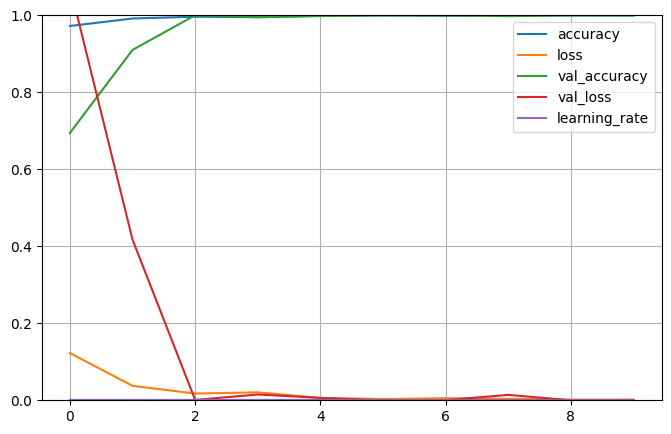

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image

# Get the class map
class_map=train_generator.class_indices

#Reverse the map so we can look up the text label by its numeric output
labels_dict={v: k for k, v in class_map.items()}
print("model class mapping:", labels_dict)

# Get the file path and original labels from the test_df
test_img_data=test_df[['file_paths','labels']].to_records(index=False).tolist()

results=[]

Print(“Generating Predictions”)

# loop through each img path and its original label
for img_path,original_label in test_img_data:
  img=image.load_img(img_path,target_size=(299,299))
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array/=255
  # Make Prediction
  prediction = model.predict(img_array, verbose=0)
  predicted_calss_idx=np.argmax(prediction)
  predicted_label=labels_dict[predicted_class_idx]

  results.append({'Image_path': img_path,
                  'predictied_Sign_Category':predicted_label,
                  'Original_label':original_label})

results_df = pd.DataFrame(results)
print("\n First 10 Predictions")
print(results_df.head(10))

print("\nVisualizing a sample of the predictions...")

# Set up a 3x3 grid for displaying 9 images
plt.figure(figsize=(10, 10))
num_images_to_show = 9
#select random samples to show
samples_indices=np.random.choice(len(results_df),
                                 min(num_images_to_shoew,len(results_df)),
                                 replace=False)
for I,idx in enumerate(sample_indices):
  img_path_display=results_df.iloc[idx]['predicted_sign_Category']
  original_label_display=results_df.iloc[idx]['Original_Label']

  # Load the original image to display it clearly
  display_img=image.load_img(img_path_display)

  # Add subplot to the 3x3 grid
  plt.subplot(3, 3, i + 1)
  plt.imshow(display_img)

  # Set the title to te predicted label,
  title_color='green' if predicted_label_display==original_label_display else 'red'
  plt.title(f"pred:{predicted_label_display}\nActual: {original_label_display}",
            fontsize=10,fontweight='bold',color=title_color)
  plt.axis('off')

plt.tight_layout()
plt.show()
